# Transformer Showdown (PyTorch): BERT vs RoBERTa vs XLNet for Twitter Emotion Classification



## 1. Install dependencies

In [1]:
!pip install -q transformers datasets evaluate accelerate sentencepiece scikit-learn matplotlib seaborn


##Imports, seeds, and GPU optimizations

In [2]:
import os
import gc
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    total_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU memory: {total_mem_gb:.1f} GB")

    # TF32 speeds up matmuls on Ampere+ GPUs (A100 in Colab Pro); harmless elsewhere.
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

    # bf16 is more numerically stable than fp16 and is supported on A100; fall back to fp16 on T4.
    USE_BF16 = torch.cuda.is_bf16_supported()
    USE_FP16 = not USE_BF16
else:
    USE_BF16 = False
    USE_FP16 = False

print(f"Mixed precision: bf16={USE_BF16}, fp16={USE_FP16}")


Device: cuda
GPU: Tesla T4
GPU memory: 15.6 GB
Mixed precision: bf16=True, fp16=False


##Load and explore the dataset



In [3]:
raw_datasets = load_dataset("dair-ai/emotion")
print(raw_datasets)

label_names = raw_datasets["train"].features["label"].names
num_labels = len(label_names)
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}
print("Labels:", label_names)

train_df = raw_datasets["train"].to_pandas()
print(f"Train: {len(raw_datasets['train'])} | Validation: {len(raw_datasets['validation'])} | Test: {len(raw_datasets['test'])}")
train_df.head()


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Train: 16000 | Validation: 2000 | Test: 2000


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


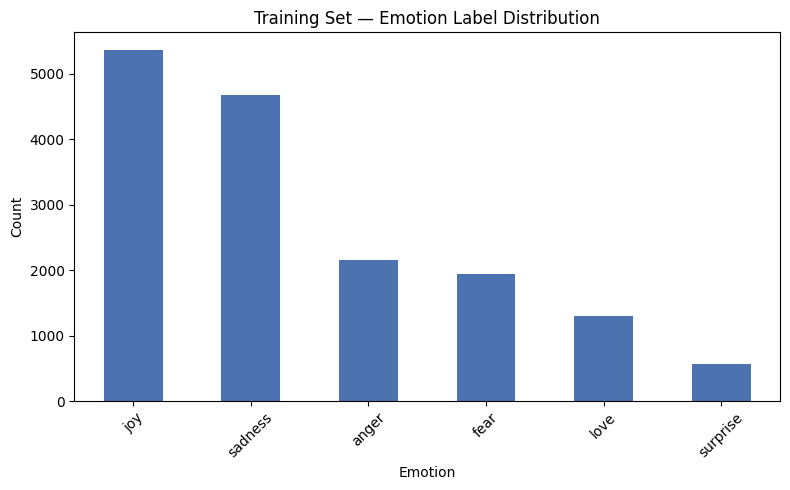

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
train_df["label"].map(id2label).value_counts().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Training Set — Emotion Label Distribution")
ax.set_xlabel("Emotion")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150)
plt.show()


##Tokenization

In [5]:
MAX_LEN = 64  # hard cap for truncation only; actual batch padding is dynamic

def make_tokenize_fn(tokenizer):
    def tokenize_fn(batch):
        return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)
    return tokenize_fn


##Metrics + generic train/evaluate function



In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


def train_and_evaluate(
    model_name,
    checkpoint,
    per_device_batch_size=32,
    grad_accum_steps=1,
    epochs=2,
    learning_rate=2e-5,
):
    print(f"\n{'='*60}\nFine-tuning {model_name} ({checkpoint})\n{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    tokenized = raw_datasets.map(make_tokenize_fn(tokenizer), batched=True)
    tokenized = tokenized.remove_columns(["text"])
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=num_labels, id2label=id2label, label2id=label2id
    ).to(device)

    args = TrainingArguments(
        output_dir=f"./results_{model_name.lower()}",
        num_train_epochs=epochs,
        per_device_train_batch_size=per_device_batch_size,
        per_device_eval_batch_size=per_device_batch_size * 2,
        gradient_accumulation_steps=grad_accum_steps,
        eval_accumulation_steps=10,
        learning_rate=learning_rate,
        weight_decay=0.01,
        warmup_ratio=0.1,
        lr_scheduler_type="linear",
        fp16=USE_FP16,
        bf16=USE_BF16,
        # group_by_length=True,          # buckets similar-length sequences -> less padding waste
        dataloader_num_workers=2,
        dataloader_pin_memory=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=50,
        report_to="none",
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    start = time.time()
    trainer.train()
    train_time = time.time() - start

    # Evaluate on the held-out test set
    test_output = trainer.predict(tokenized["test"])
    y_pred = np.argmax(test_output.predictions, axis=1)
    y_true = test_output.label_ids

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=label_names, zero_division=0)

    print(f"\n{model_name} test accuracy: {acc:.4f} | weighted F1: {f1:.4f} | training time: {train_time/60:.1f} min")
    print(report)

    # Pull per-epoch train/val loss out of the Trainer's log history for plotting later
    log_history = trainer.state.log_history

    result = {
        "model_name": model_name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "train_time_sec": train_time,
        "log_history": log_history,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
    }

    # --- Free GPU memory before loading the next model (important on a single Colab GPU) ---
    del trainer, model
    gc.collect()
    torch.cuda.empty_cache()

    return result

##BERT

In [11]:
bert_results = train_and_evaluate("BERT", "bert-base-uncased")



Fine-tuning BERT (bert-base-uncased)


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.251320,0.209249,0.924000,0.927613,0.924000,0.924675
2,0.138019,0.169218,0.930000,0.930118,0.930000,0.929895


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


BERT test accuracy: 0.9245 | weighted F1: 0.9243 | training time: 7.7 min
              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       581
         joy       0.96      0.94      0.95       695
        love       0.82      0.88      0.85       159
       anger       0.92      0.92      0.92       275
        fear       0.87      0.90      0.88       224
    surprise       0.78      0.65      0.71        66

    accuracy                           0.92      2000
   macro avg       0.88      0.87      0.88      2000
weighted avg       0.92      0.92      0.92      2000



##RoBERTa

In [12]:
roberta_results = train_and_evaluate("RoBERTa", "roberta-base")



Fine-tuning RoBERTa (roberta-base)


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.276771,0.215365,0.922500,0.925794,0.922500,0.923119
2,0.149533,0.166045,0.928000,0.930064,0.928000,0.928417


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


RoBERTa test accuracy: 0.9300 | weighted F1: 0.9306 | training time: 9.2 min
              precision    recall  f1-score   support

     sadness       0.97      0.95      0.96       581
         joy       0.97      0.93      0.95       695
        love       0.80      0.94      0.86       159
       anger       0.92      0.95      0.93       275
        fear       0.87      0.90      0.89       224
    surprise       0.80      0.74      0.77        66

    accuracy                           0.93      2000
   macro avg       0.89      0.90      0.89      2000
weighted avg       0.93      0.93      0.93      2000



##XLNet



In [13]:
xlnet_results = train_and_evaluate("XLNet", "xlnet-base-cased", per_device_batch_size=16, grad_accum_steps=2)



Fine-tuning XLNet (xlnet-base-cased)


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.822896,0.281953,0.898500,0.900370,0.898500,0.899019
2,0.421209,0.202301,0.921500,0.923777,0.921500,0.922149


model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


XLNet test accuracy: 0.9150 | weighted F1: 0.9158 | training time: 10.0 min
              precision    recall  f1-score   support

     sadness       0.95      0.95      0.95       581
         joy       0.96      0.92      0.94       695
        love       0.79      0.89      0.83       159
       anger       0.92      0.90      0.91       275
        fear       0.86      0.89      0.87       224
    surprise       0.73      0.79      0.76        66

    accuracy                           0.92      2000
   macro avg       0.87      0.89      0.88      2000
weighted avg       0.92      0.92      0.92      2000



## 9. Side-by-side comparison table

In [14]:
all_results = [bert_results, roberta_results, xlnet_results]

comparison_df = pd.DataFrame([{
    "Model": r["model_name"],
    "Accuracy": r["accuracy"],
    "Precision": r["precision"],
    "Recall": r["recall"],
    "F1 Score": r["f1"],
    "Training Time (min)": r["train_time_sec"] / 60,
} for r in all_results]).round(4)

comparison_df.to_csv("model_comparison.csv", index=False)
comparison_df


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (min)
0,BERT,0.9245,0.9247,0.9245,0.9243,7.6571
1,RoBERTa,0.9300,0.9326,0.9300,0.9306,9.2086
2,XLNet,0.9150,0.9175,0.9150,0.9158,10.0075


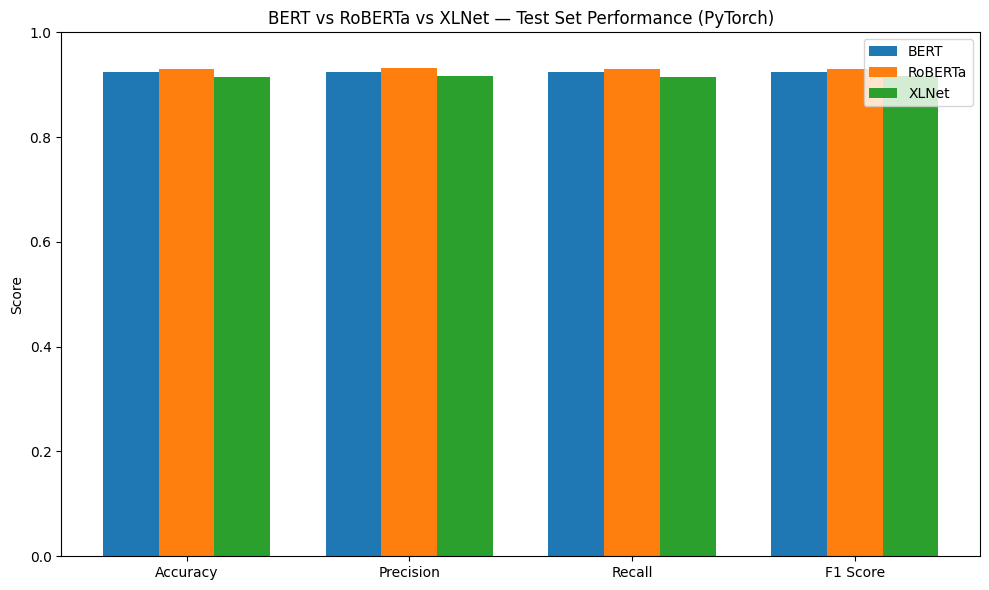

In [15]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
keys = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, r in enumerate(all_results):
    values = [r[k] for k in keys]
    ax.bar(x + i * width, values, width, label=r["model_name"])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("BERT vs RoBERTa vs XLNet — Test Set Performance (PyTorch)")
ax.legend()
plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=150)
plt.show()


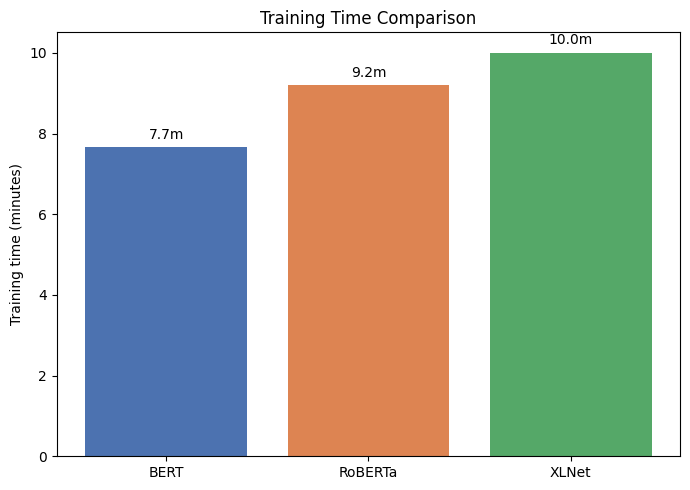

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
names = [r["model_name"] for r in all_results]
times = [r["train_time_sec"] / 60 for r in all_results]
bars = ax.bar(names, times, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Training time (minutes)")
ax.set_title("Training Time Comparison")
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f"{t:.1f}m", ha="center")
plt.tight_layout()
plt.savefig("training_time_comparison.png", dpi=150)
plt.show()


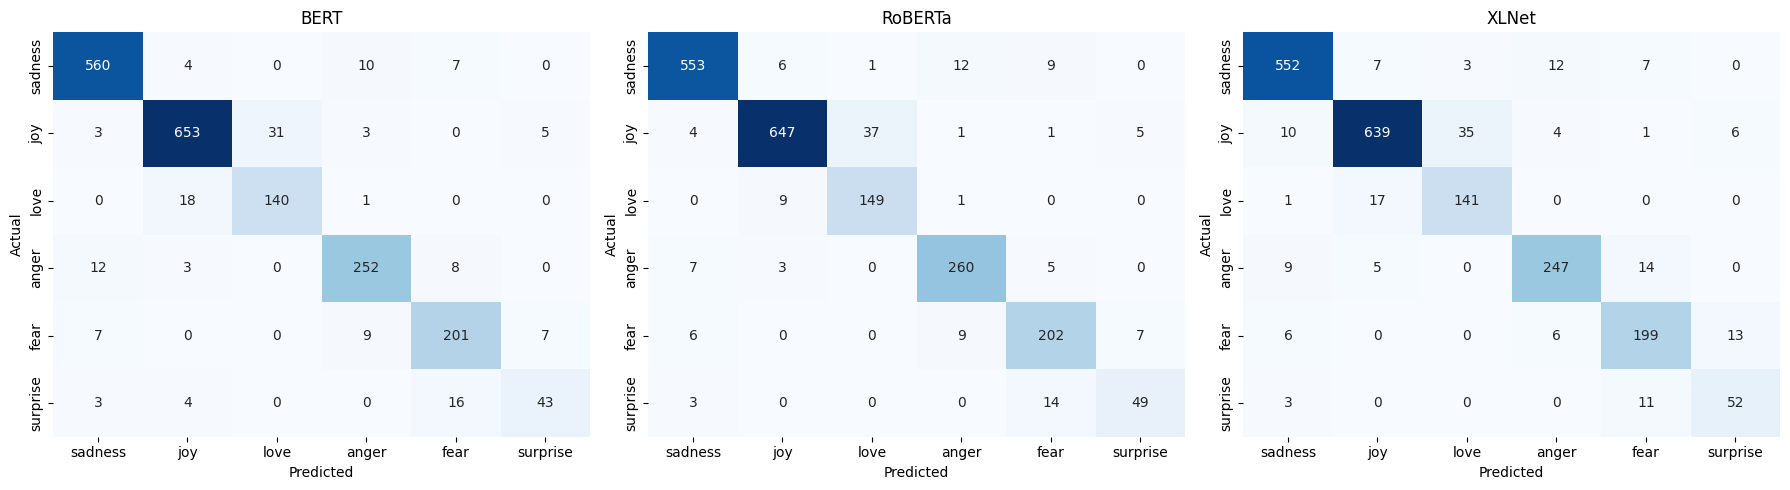

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, r in zip(axes, all_results):
    sns.heatmap(r["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names, ax=ax, cbar=False)
    ax.set_title(r["model_name"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()


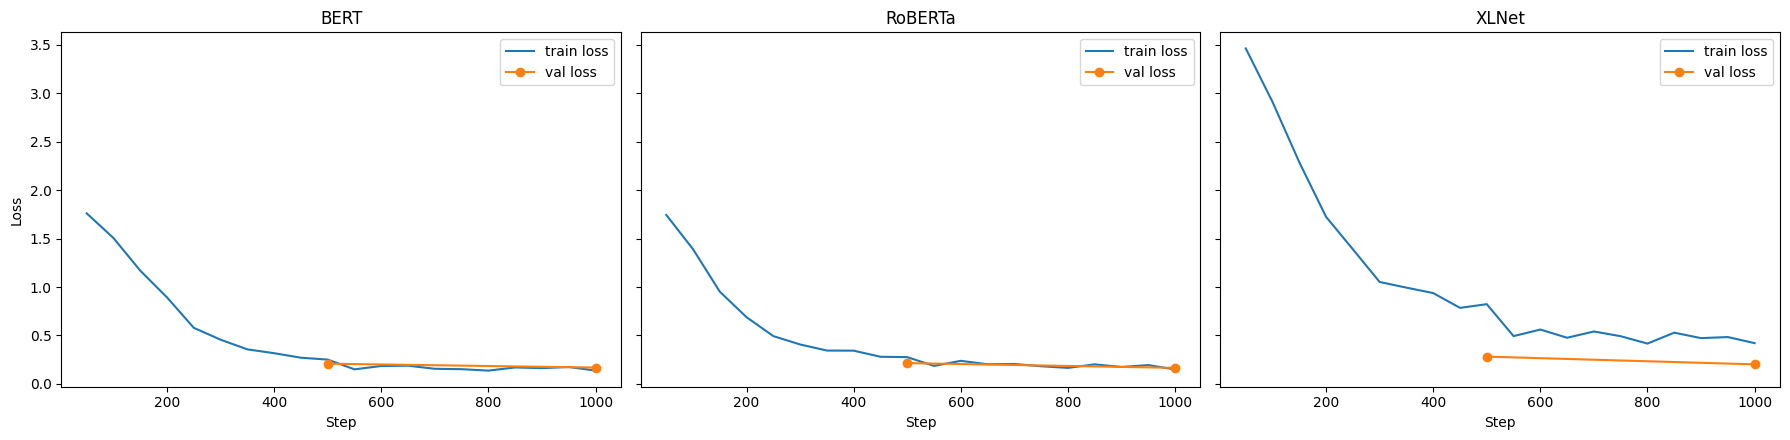

In [18]:
def extract_loss_curve(log_history):
    train_loss = [(e["step"], e["loss"]) for e in log_history if "loss" in e]
    val_loss = [(e["step"], e["eval_loss"]) for e in log_history if "eval_loss" in e]
    return train_loss, val_loss

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
for ax, r in zip(axes, all_results):
    train_loss, val_loss = extract_loss_curve(r["log_history"])
    if train_loss:
        steps, losses = zip(*train_loss)
        ax.plot(steps, losses, label="train loss")
    if val_loss:
        steps, losses = zip(*val_loss)
        ax.plot(steps, losses, label="val loss", marker="o")
    ax.set_title(r["model_name"])
    ax.set_xlabel("Step")
    ax.legend()
axes[0].set_ylabel("Loss")
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()




```python
trainer.save_model(f"./{model_name.lower()}_emotion_model")
tokenizer.save_pretrained(f"./{model_name.lower()}_emotion_model")
```


## 12. Conclusion

Fill this in once you've run the notebook — the printed comparison table and charts above
give you everything needed. A full written report/comparison template is provided separately
as `report_template.md`.

**Talking points for an interview / write-up:**
- **BERT**: bidirectional encoder, pretrained via masked-LM + next-sentence-prediction.
- **RoBERTa**: same architecture as BERT, but drops NSP, uses dynamic masking, and trains
  longer on more data with larger batches — usually a modest but consistent edge over BERT.
- **XLNet**: permutation-based autoregressive pretraining captures bidirectional context
  without an artificial `[MASK]` token, at the cost of more expensive training (as you likely
  saw in the training-time chart above).
- On short, informal text like tweets, differences between the three are often within a few
  points of F1 — dataset size, learning rate, and epoch count often matter as much as the
  choice of architecture.
